# Cat28 인자 추출 — 샘플 레코드 한 건을 눈으로 따라가기

**목적.** 계획서 5.1절이 정의한 **Cat28 인자 28개**(4.1절의 6그룹)가 5분 세그먼트 하나에서
어떻게 계산되는지, 모든 중간 단계를 그림으로 확인한다. 계산 로직은 전부
`extract_factors_ctu.py`에서 import한다 — 이 노트북은 같은 코드의 **시각화 판**이며,
마지막 셀에서 전체 배치 결과(`log/ctu_segment_factors.csv`)와 값이 일치함을 검증한다.

**샘플.** 레코드 **1001**(제대동맥혈 pH 7.14, 1분 Apgar 6 — 두 기준 모두 비정상)의
5분 세그먼트 **#10**. 계획서 그림 5-1-1과 같은 세그먼트다.

**단계** — 계획서 5.1절의 3단계 구조를 그대로 따른다.
1. 세그먼트 분할과 결측 규칙 (제외 기준 30%)
2. 1단계: 전처리 — 짧은 결측 선형 보간
3. 2단계: FIGO 반복 기저선 $B$ — 수렴 과정 시각화
4. 3단계: 이벤트 검출 — 감속·가속·수축 정점과 감속 유형 분류
5. 분포 인자 — FHR 히스토그램
6. 양신호 결합 인자 — FHR-TOCO 시간차 상관
7. **Cat28 전체 표**와 배치 CSV 대조 검증

## 0. 준비

계산 코드는 `extract_factors_ctu.py`에서 그대로 가져온다. 여기서 새로 정의하는 함수는 없다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
sys.path.insert(0, str(Path.cwd()))
from extract_factors_ctu import (
    BRADY, CAT28, DATA, FS, HIST_BINS, MAX_LAG, MAX_MISSING, SEG_N, TACHY,
    _corr, extract_segment, read_signals, trim_edge_missing,
)
from features import (   # A.2 규칙 구현 — 재현 실험과 같은 코드
    ACC_MIN_BPM, BASELINE_TOL, DEC_MIN_BPM, classify_deceleration,
    detect_accelerations, detect_contractions, detect_decelerations,
    estimate_baseline, preprocess_for_features,
)

try:
    fm.findfont("NanumGothic", fallback_to_default=False)
    plt.rcParams["font.family"] = "NanumGothic"
except ValueError:
    pass
plt.rcParams["axes.unicode_minus"] = False

C_FHR, C_UC = "#e34948", "#2a78d6"
C_DECEL, C_ACCEL, C_BASE = "#eb6834", "#1baf7a", "#1c2430"
MUTED = "#5a6673"

RID, SEG = "1001", 10
print(f"데이터 경로: {DATA}")
print(f"샘플: 레코드 {RID}, 세그먼트 #{SEG} (Cat28 인자 {len(CAT28)}개)")

데이터 경로: /home/yabsed/Documents/summer26/fetalguard-ai/project/experiment-15/ctu-hub-ctgdb
샘플: 레코드 1001, 세그먼트 #10 (Cat28 인자 28개)


## 1. 세그먼트 분할과 결측 규칙

레코드의 양끝 결측을 제거한 뒤 5분(= 1,200표본 @ 4 Hz) 단위로 자른다.
신호값 0은 심박수가 아니라 **신호 소실(결측)**이므로, 결측이 세그먼트의 **30%를 초과하면
그 세그먼트는 인자 계산에서 제외**한다 (계획서 5.1절 1단계).

In [2]:
fhr_full, uc_full, meta, fs = read_signals(DATA / f"{RID}.hea")
assert fs == FS
fhr_full, uc_full = trim_edge_missing(fhr_full, uc_full)
n_seg = len(fhr_full) // SEG_N

miss = [float((fhr_full[k * SEG_N:(k + 1) * SEG_N] == 0).mean()) for k in range(n_seg)]
tbl = pd.DataFrame({"세그먼트": range(n_seg), "결측률": miss})
tbl["판정"] = np.where(tbl["결측률"] > MAX_MISSING, "제외", "사용")
print(f"레코드 {RID}: 양끝 제거 후 {len(fhr_full) / FS / 60:.1f}분 → 5분 세그먼트 {n_seg}개")
print(f"pH {meta['pH']:.2f}, Apgar1 {meta['Apgar1']:.0f}")
tbl.style.format({"결측률": "{:.1%}"})

레코드 1001: 양끝 제거 후 79.2분 → 5분 세그먼트 15개
pH 7.14, Apgar1 6


,세그먼트,결측률,판정
0,0,0.7%,사용
1,1,0.8%,사용
2,2,0.4%,사용
3,3,1.2%,사용
4,4,16.6%,사용
5,5,22.3%,사용
6,6,13.9%,사용
7,7,8.3%,사용
8,8,20.4%,사용
9,9,13.9%,사용


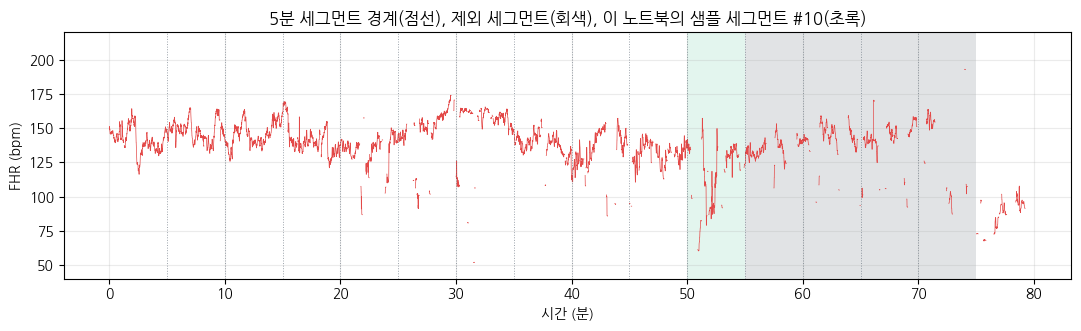

In [3]:
t_full = np.arange(len(fhr_full)) / FS / 60
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(t_full, np.where(fhr_full == 0, np.nan, fhr_full), lw=0.5, color=C_FHR)
for k in range(1, n_seg):
    ax.axvline(k * 5, color=MUTED, ls=":", lw=0.7, alpha=0.6)
for k, m in enumerate(miss):
    if m > MAX_MISSING:
        ax.axvspan(k * 5, (k + 1) * 5, color=MUTED, alpha=0.18, lw=0)
ax.axvspan(SEG * 5, (SEG + 1) * 5, color=C_ACCEL, alpha=0.12, lw=0)
ax.set_ylim(40, 220)
ax.set_xlabel("시간 (분)")
ax.set_ylabel("FHR (bpm)")
ax.set_title(f"5분 세그먼트 경계(점선), 제외 세그먼트(회색), 이 노트북의 샘플 세그먼트 #{SEG}(초록)")
ax.grid(alpha=0.25)
plt.show()

## 2. 1단계 — 전처리: A.2 특성 전용 전처리

사용 판정된 세그먼트에는 계획서 5.1 1단계(= A.2의 특성 전용 전처리)를 적용한다 —
**15초 미만의 짧은 결측 선형 보간 → 30초 롤링 창 평활(유효 표본만 평균) → 남은 결측
선형 보간**. 수축의 "종형 45~120초" 판정이 평활에 의존하므로, 이후 모든 인자는 이
전처리 완료 신호에서 계산된다.

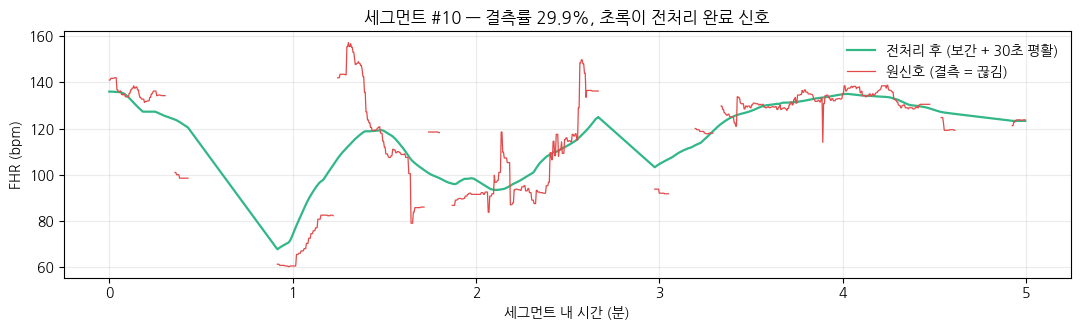

In [4]:
seg_raw_f = fhr_full[SEG * SEG_N:(SEG + 1) * SEG_N]
seg_raw_t = uc_full[SEG * SEG_N:(SEG + 1) * SEG_N]
seg_f, seg_t = preprocess_for_features(seg_raw_f, seg_raw_t, FS)
t = np.arange(SEG_N) / FS / 60   # 세그먼트 내 시간 (분)

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(t, seg_f, lw=1.6, color=C_ACCEL, alpha=0.9, label="전처리 후 (보간 + 30초 평활)")
ax.plot(t, np.where(seg_raw_f == 0, np.nan, seg_raw_f), lw=0.9, color=C_FHR, label="원신호 (결측 = 끊김)")
ax.set_xlabel("세그먼트 내 시간 (분)")
ax.set_ylabel("FHR (bpm)")
ax.set_title(f"세그먼트 #{SEG} — 결측률 {float((seg_raw_f == 0).mean()):.1%}, 초록이 전처리 완료 신호")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

## 3. 2단계 — FIGO 반복 기저선 $B$

기저심박수는 가속·감속을 제외한 안정 구간의 대푯값이다. A.2 명세대로 창의 **평균**
$B^{(0)}$에서 시작해, 현재 기저선에서 **±15 bpm 이상 벗어난 표본을 제외하고 평균을
재계산**하는 과정을 변화량이 0.5 bpm 미만이 될 때까지 반복한다. (원문은 10분 창으로
초기 추정하지만 세그먼트가 5분이라 창 전체를 쓴다 — 계획서 5.1이 명시한 제약이다.)

아래 셀은 `estimate_baseline`과 같은 반복을 수행하며 매 반복의 $B^{(k)}$를 기록한다
(마지막에 모듈 함수의 결과와 일치를 확인한다).

반복 궤적 B^(k): 114.30 → 116.66 → 118.99 → 121.11 → 123.15 → 123.93 → 수렴 124.24 bpm
단순 중앙값과의 차이: +6.42 bpm (감속이 깊을수록 중앙값은 아래로 끌려간다 — 계획서 5.1절 2단계의 근거)


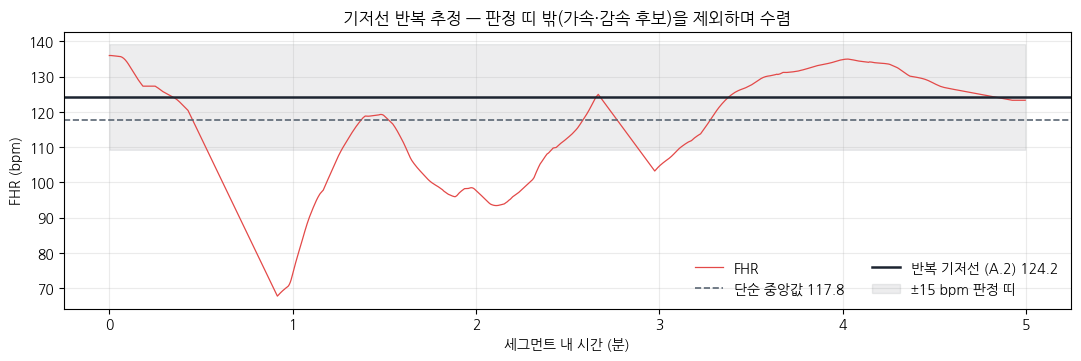

In [5]:
trace = [float(np.mean(seg_f))]
while True:
    keep = np.abs(seg_f - trace[-1]) < DEC_MIN_BPM
    new = float(np.mean(seg_f[keep])) if keep.any() else trace[-1]
    if abs(new - trace[-1]) < BASELINE_TOL or len(trace) > 50:
        break
    trace.append(new)

base, keep = estimate_baseline(seg_f, FS)
assert abs(base - trace[-1]) < BASELINE_TOL, "모듈 함수와 반복 결과 불일치"
print("반복 궤적 B^(k):", " → ".join(f"{b:.2f}" for b in trace), f"→ 수렴 {base:.2f} bpm")
print(f"단순 중앙값과의 차이: {base - float(np.median(seg_f)):+.2f} bpm "
      "(감속이 깊을수록 중앙값은 아래로 끌려간다 — 계획서 5.1절 2단계의 근거)")

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(t, seg_f, lw=0.9, color=C_FHR, label="FHR")
ax.axhline(np.median(seg_f), color=MUTED, lw=1.2, ls="--", label=f"단순 중앙값 {np.median(seg_f):.1f}")
ax.axhline(base, color=C_BASE, lw=1.8, label=f"반복 기저선 (A.2) {base:.1f}")
ax.fill_between(t, base - DEC_MIN_BPM, base + ACC_MIN_BPM, color=C_BASE, alpha=0.08,
                label="±15 bpm 판정 띠")
ax.set_xlabel("세그먼트 내 시간 (분)")
ax.set_ylabel("FHR (bpm)")
ax.set_title("기저선 반복 추정 — 판정 띠 밖(가속·감속 후보)을 제외하며 수렴")
ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.25)
plt.show()

## 4. 3단계 — 이벤트 검출과 감속 유형 분류

검출과 유형 분류는 **Chiou et al.의 medRxiv 프리프린트 Appendix A.2**가 명시한 규칙을
그대로 따른다. 계획서 4.1절이 이 집합을 "Chiou et al.의 FIGO 17개를 포괄한다"고
선언하므로, 겹치는 인자는 그들의 계산 규칙을 써야 한다.

- **감속** $D$: 기저선 −15 bpm 초과 하강이 15초 초과 지속
- **가속** $A$: +15 bpm 초과, 15초 초과 지속, **개시→정점 30초 미만**, 총 지속 10분 미만
- **수축** $C$: 정점이 아니라 **구간**이다 — 종형 상승이며 총 지속 **45~120초**인 융기만
  센다. 각 수축은 개시·정점·종료를 갖는다.

감속 유형은 다음 순서로 판정한다.

1. **후기** — 감속 **개시**가 최근접 수축 **개시** + 20초보다 늦고 수축 종료 전
2. 후기가 아니면 **지속시간**으로 — < 3분 조기, 3~5분 장기, > 5분 중증
   (중증이 심박 수치가 아니라 지속시간 기준임에 주의)
3. **변이** — 위 분류와 **독립**으로, 개시→최저점 < 30초인 감속을 따로 센다

따라서 조기·후기·장기·중증은 $D$의 **분할**이고(넷의 합 = 감속 수), 변이만 겹쳐 계수된다.
5분 세그먼트에서는 장기·중증이 구조적으로 거의/전혀 나타나지 않는다 — A.2의 유형 체계가
30분 창을 전제로 설계된 결과다(계획서 4.1절).

In [6]:
decs = detect_decelerations(seg_f, base, FS)
accs = detect_accelerations(seg_f, base, FS)
contractions = detect_contractions(seg_t, FS)
KOR = {"early": "조기", "late": "후기", "prolonged": "장기", "severe": "중증"}

rows = []
for i, (s, e) in enumerate(decs, 1):
    nadir = s + int(np.argmin(seg_f[s:e]))
    main, is_var = classify_deceleration(s, e, nadir, contractions, FS)
    rows.append({"감속": i, "시작(분)": s / FS / 60, "지속(초)": (e - s) / FS,
                 "개시→최저(초)": (nadir - s) / FS,
                 "최저(bpm)": seg_f[nadir], "깊이(bpm)": base - seg_f[nadir],
                 "유형": KOR[main] + ("+변이" if is_var else "")})
print(f"감속 {len(decs)}회 · 가속 {len(accs)}회 · 수축 {len(contractions)}회")
pd.DataFrame(rows).round(2)

감속 2회 · 가속 0회 · 수축 2회


,감속,시작(분),지속(초),개시→최저(초),최저(bpm),깊이(bpm),유형
0,1,0.53,44.25,23.00,67.71,56.53,후기+변이
1,2,1.62,47.25,29.25,93.42,30.83,조기+변이


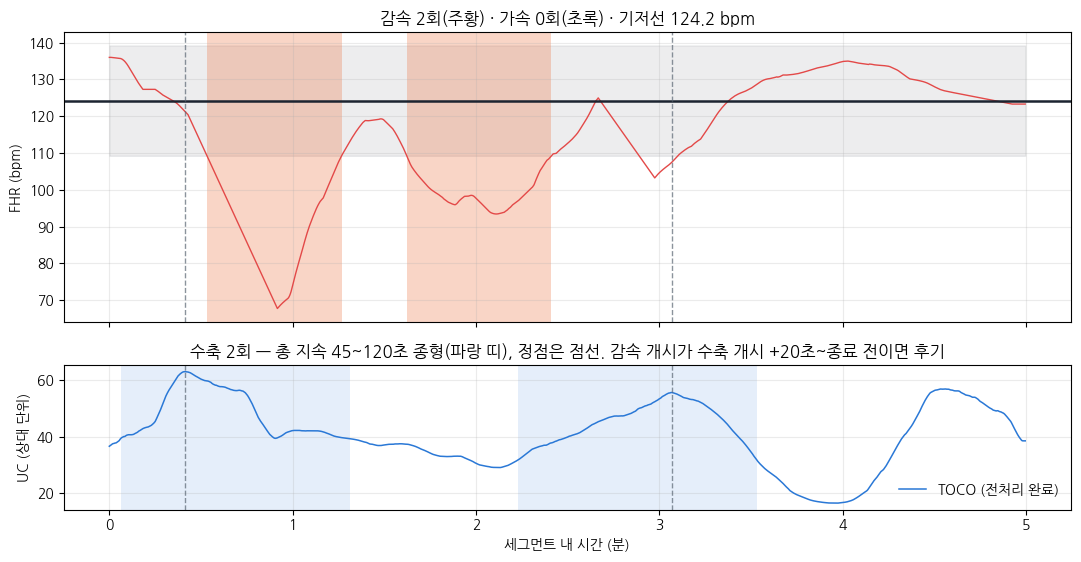

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6.2), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.plot(t, seg_f, lw=1.0, color=C_FHR)
ax.axhline(base, color=C_BASE, lw=1.8)
ax.fill_between(t, base - DEC_MIN_BPM, base + ACC_MIN_BPM, color=C_BASE, alpha=0.08)
for s, e in decs:
    ax.axvspan(t[s], t[e - 1], color=C_DECEL, alpha=0.28, lw=0)
for s, e in accs:
    ax.axvspan(t[s], t[e - 1], color=C_ACCEL, alpha=0.28, lw=0)
ax.set_ylabel("FHR (bpm)")
ax.set_title(f"감속 {len(decs)}회(주황) · 가속 {len(accs)}회(초록) · 기저선 {base:.1f} bpm")
ax2 = axes[1]
ax2.plot(t, seg_t, lw=1.1, color=C_UC, label="TOCO (전처리 완료)")
for _on, p, _end in contractions:
    ax2.axvspan(t[_on], t[min(_end, SEG_N - 1)], color=C_UC, alpha=0.12, lw=0)
    for a in axes:
        a.axvline(t[p], color=MUTED, ls="--", lw=1, alpha=0.7)
ax2.set_ylabel("UC (상대 단위)")
ax2.set_xlabel("세그먼트 내 시간 (분)")
ax2.set_title(f"수축 {len(contractions)}회 — 총 지속 45~120초 종형(파랑 띠), 정점은 점선. "
              "감속 개시가 수축 개시 +20초~종료 전이면 후기")
ax2.legend(frameon=False)
for a in axes:
    a.grid(alpha=0.25)
plt.show()

## 5. 분포 인자 — FHR 히스토그램

세그먼트 FHR 분포의 **중앙값·최빈값(24구간 히스토그램)·폭**이 기저선·분포 그룹(②)의
인자다. 서맥(<110 bpm)·빈맥(>160 bpm) 표본 비율은 범위 일탈 그룹(④)이다.

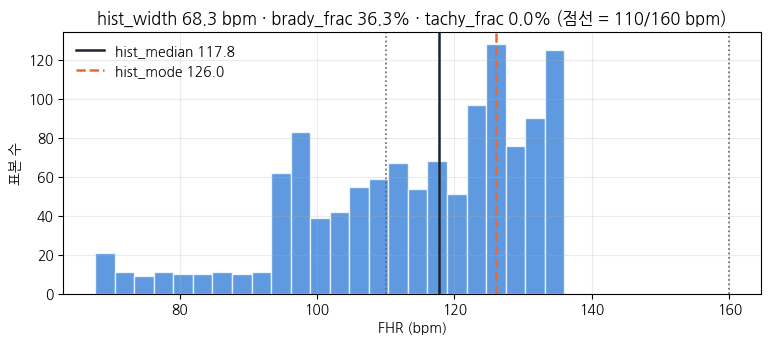

In [8]:
hist, edges = np.histogram(seg_f, bins=HIST_BINS)
k_mode = int(np.argmax(hist))
mode = (edges[k_mode] + edges[k_mode + 1]) / 2

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(edges[:-1], hist, width=np.diff(edges), align="edge",
       color=C_UC, alpha=0.75, edgecolor="white")
ax.axvline(np.median(seg_f), color=C_BASE, lw=1.8, label=f"hist_median {np.median(seg_f):.1f}")
ax.axvline(mode, color=C_DECEL, lw=1.8, ls="--", label=f"hist_mode {mode:.1f}")
ax.axvline(BRADY, color=MUTED, lw=1.2, ls=":")
ax.axvline(TACHY, color=MUTED, lw=1.2, ls=":")
ax.set_xlabel("FHR (bpm)")
ax.set_ylabel("표본 수")
ax.set_title(f"hist_width {seg_f.max() - seg_f.min():.1f} bpm · "
             f"brady_frac {(seg_f < BRADY).mean():.1%} · tachy_frac {(seg_f > TACHY).mean():.1%} "
             "(점선 = 110/160 bpm)")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

## 6. 양신호 결합 인자 — FHR-TOCO 시간차 상관

**동시 피어슨 상관**(`ft_corr0`)과, FHR를 ±60초 범위에서 1초 간격으로 밀며 겹치는
구간마다 **다시 중심화·표준화하는 피어슨 상관**의 최솟값(`ft_corr_min`)과 그
시간차(`ft_corr_min_lag_s`)를 계산한다 — 계획서 5.1이 명시한 정의 그대로이며, 전역
표준화 후 곱 평균 방식(겹친 창의 실제 중심·산포가 전역 값과 어긋나 상관을 0 쪽으로
누른다; `verify_design_choices.py` §3)이 아니다. 계산은 배치와 같은 `_corr`를 쓴다.
lag가 양수면 FHR 하강이 수축에 **후행**한다는 뜻 — 이산적 감속 계수(조기/후기)가 버리는
연속적 시간 관계를 보존하는, Cat28이 Chiou et al.의 17개에 추가한 인자다 (계획서 4.1절 ⑥).

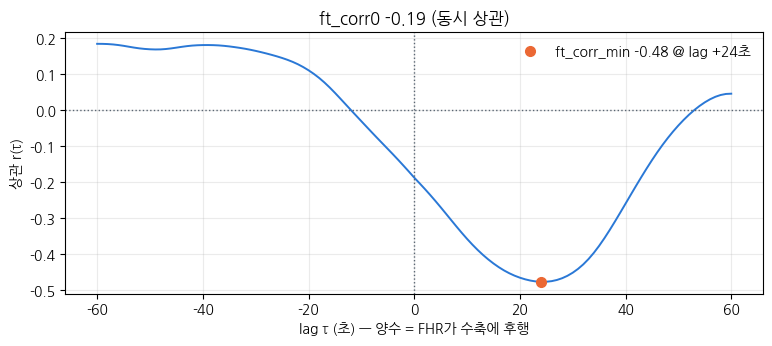

In [9]:
# 배치와 동일한 _corr(겹치는 구간의 피어슨 상관)로 lag 곡선을 그린다
lags, rs = [0], [_corr(seg_f, seg_t)]
for lag in range(-MAX_LAG, MAX_LAG + 1, FS):
    if lag == 0:
        continue
    a = seg_f[lag:] if lag > 0 else seg_f[:lag]
    b = seg_t[:-lag] if lag > 0 else seg_t[-lag:]
    lags.append(lag)
    rs.append(_corr(a, b))
order = np.argsort(lags)
lags_s = np.array(lags)[order] / FS
rs = np.array(rs)[order]
i_min = int(np.argmin(rs))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(lags_s, rs, lw=1.4, color=C_UC)
ax.axvline(0, color=MUTED, lw=1, ls=":")
ax.axhline(0, color=MUTED, lw=1, ls=":")
ax.plot(lags_s[i_min], rs[i_min], "o", color=C_DECEL, ms=7,
        label=f"ft_corr_min {rs[i_min]:.2f} @ lag {lags_s[i_min]:+.0f}초")
ax.set_xlabel("lag τ (초) — 양수 = FHR가 수축에 후행")
ax.set_ylabel("상관 r(τ)")
ax.set_title(f"ft_corr0 {rs[lags_s == 0][0]:.2f} (동시 상관)")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

## 7. Cat28 전체 표 — 그리고 배치 결과와의 일치 검증

`extract_segment`가 이 세그먼트에서 산출한 **28개 인자 전부**를 계획서 4.1절의 6그룹으로
묶어 표로 본다. 마지막으로 `extract_factors_ctu.py`가 552건 전체를 돌려 만든
`log/ctu_segment_factors.csv`의 같은 행과 대조해, 이 노트북의 값이 배치 파이프라인과
동일함을 확인한다.

In [10]:
f = extract_segment(seg_f, seg_t)
assert set(f) == set(CAT28) and len(f) == 28

GROUPS = {
    "① 신호 수준": ["fhr_mean", "fhr_min", "fhr_max", "fhr_sd"],
    "② 기저선·분포": ["figo_baseline", "hist_median", "hist_mode", "hist_width"],
    "③ 변이도": ["stv", "figo_baseline_var"],
    "④ 범위 일탈": ["brady_frac", "tachy_frac"],
    "⑤ 감속·가속": ["n_decel", "decel_max_depth", "decel_time_frac", "n_accel",
                  "n_early_decel", "n_late_decel", "n_variable_decel",
                  "n_severe_decel", "n_prolonged_decel"],
    "⑥ 자궁수축·결합": ["toco_mean", "toco_max", "toco_sd", "n_contractions",
                    "ft_corr0", "ft_corr_min", "ft_corr_min_lag_s"],
}
assert sum(len(v) for v in GROUPS.values()) == 28
pd.DataFrame([{"그룹": g, "인자": k, "값": round(f[k], 3)}
              for g, keys in GROUPS.items() for k in keys])

,그룹,인자,값
0,① 신호 수준,fhr_mean,114.304
1,① 신호 수준,fhr_min,67.713
2,① 신호 수준,fhr_max,136.008
3,① 신호 수준,fhr_sd,16.379
4,② 기저선·분포,figo_baseline,124.240
5,② 기저선·분포,hist_median,117.823
6,② 기저선·분포,hist_mode,126.048
7,② 기저선·분포,hist_width,68.296
8,③ 변이도,stv,0.207
9,③ 변이도,figo_baseline_var,0.766


In [11]:
csv = pd.read_csv(Path("log") / "ctu_segment_factors.csv")
row = csv[(csv["record_id"] == int(RID)) & (csv["seg_idx"] == SEG)].iloc[0]
diffs = {k: (f[k], row[k]) for k in CAT28 if not np.isclose(f[k], row[k])}
assert not diffs, f"배치 CSV와 불일치: {diffs}"
print(f"검증 통과 — 레코드 {RID} 세그먼트 #{SEG}의 Cat28 인자 28개가 "
      "배치 결과(log/ctu_segment_factors.csv)와 전부 일치한다.")
print(f"배치 CSV 규모: 세그먼트 {len(csv):,}개 × 인자 {len(CAT28)}개")

검증 통과 — 레코드 1001 세그먼트 #10의 Cat28 인자 28개가 배치 결과(log/ctu_segment_factors.csv)와 전부 일치한다.
배치 CSV 규모: 세그먼트 6,400개 × 인자 28개


## 정리

- 계획서 5.1절의 3단계(전처리 → FIGO 반복 기저선 → 이벤트 검출)를 샘플 세그먼트 하나에서
  전부 시각화했고, 산출된 **Cat28 인자 28개**가 배치 파이프라인과 일치함을 검증했다.
- 552건 전체의 변환 결과: `log/ctu_segment_factors.csv` (요약: `log/summary.md`)
- 레코드별 판정 근거 시각화 552장: `figures/records/` (`make_record_figures.py`)
- 계획서 그림 5-1-1: `figures/poc_factor_anatomy.png` (`make_figure.py`)